# 💡 白话入门：基金到底是什么？

## 为什么写这篇

金融圈有一个毛病——喜欢把简单的事情用复杂的词包装。

- "基金净值" 其实就是 **每份值多少钱**
- "最大回撤" 其实就是 **最惨的时候亏了多少**
- "定投" 其实就是 **定期定额存钱买基金**

这篇 Notebook 用大白话解释这些概念，**零基础也能看懂**。

## 读完这篇你会明白

1. 基金到底是什么东西
2. 为什么有人赚有人亏
3. 定投为什么适合普通人
4. 怎么用数据做决策而不是凭感觉

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei"]
plt.rcParams["axes.unicode_minus"] = False

from scripts.data.client import get_fund_nav
from scripts.utils import viz

print("✅ 准备就绪")

✅ 准备就绪


## 第一讲：基金是什么？—— 用"拼单吃饭"来理解

假设你和 9 个朋友想吃饭，但你们都不会做饭。
**解决办法**：每人出 100 块，凑 1000 块，请一个专业厨师来做。

👆 这就是基金的本质：

| 吃饭的例子 | 基金的对应 |
|------------|-----------|
| 你出 100 块 | 你是"投资者" |
| 凑的 1000 块 | 就是"基金" |
| 专业厨师 | "基金经理" |
| 你的 100 块份额 | 你的"基金份额" |
| 饭做得好坏 | "基金收益" |

**三句话总结：**
- ① 基金 = 大家把钱凑在一起，交给专业的人去投资
- ② 你买基金 = 你出钱，基金经理帮你买卖股票/债券
- ③ 基金涨了你就赚，跌了你就亏

---

## 第二讲：净值——每份基金现在值多少钱

继续用吃饭的例子：
- 你出了 100 块，你手里有 1 份"饭票"
- 如果厨师做得特别好，有人愿意出 120 块买你的饭票
  → 饭票从 100 涨到 120，净值就是 **1.2**
- 如果厨师搞砸了，饭票只值 80 块
  → 净值就是 **0.8**，你亏了 20%

下面用一个模拟的故事来理解：

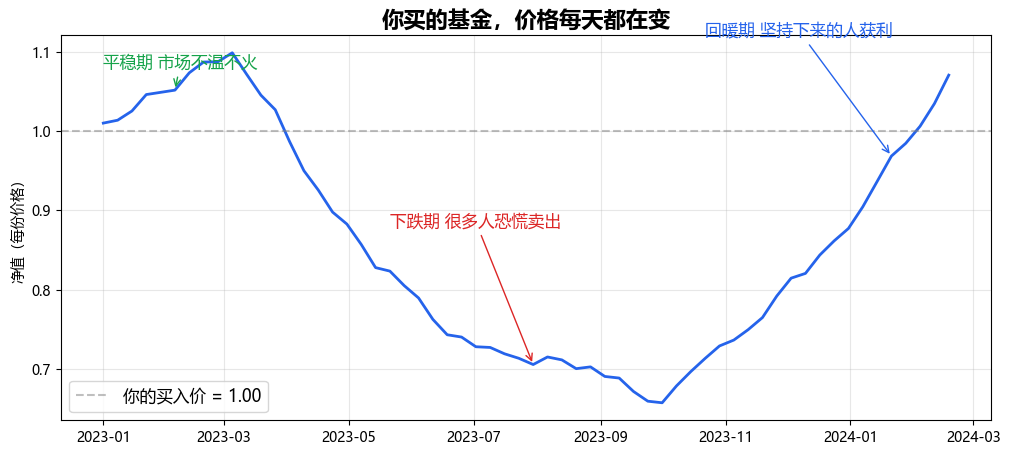


📊 故事复盘：
   如果你在 1.00 买入，坚持到今天是 1.07，盈利 7%
   但如果你在下跌期（虚线以下）恐慌卖出，不仅没赚反而亏了

💡 第一个道理：净值短期波动 = 正常现象
   只要没卖出，就只是「账面浮动」，不是「实际亏损」


In [3]:
# 故事：小明在 2023 年初买了基金，经历了完整的涨跌周期
dates = pd.date_range("2023-01-01", periods=60, freq="W")
np.random.seed(42)

story_prices = []
price = 1.00
for i in range(60):
    if i < 10:
        change = 0.005   # 刚开始平稳
    elif i < 25:
        change = -0.02   # 市场不好，持续下跌
    elif i < 40:
        change = -0.005  # 跌势减缓
    else:
        change = 0.025   # 市场回暖，持续上涨
    price *= (1 + change + np.random.normal(0, 0.01))
    story_prices.append(price)

story_nav = pd.DataFrame({"date": dates, "nav": story_prices})

# 画图讲解
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(story_nav["date"], story_nav["nav"], color="#2563EB", linewidth=2)
ax.axhline(y=1.0, color="gray", linestyle="--", alpha=0.5, label="你的买入价 = 1.00")

# 标注三个关键阶段
ax.annotate("平稳期 市场不温不火", xy=(story_nav["date"].iloc[5], story_nav["nav"].iloc[5]),
            xytext=(story_nav["date"].iloc[0], 1.08), fontsize=12, color="#16A34A",
            arrowprops=dict(arrowstyle="->", color="#16A34A"))
ax.annotate("下跌期 很多人恐慌卖出", xy=(story_nav["date"].iloc[30], story_nav["nav"].iloc[30]),
            xytext=(story_nav["date"].iloc[20], 0.88), fontsize=12, color="#DC2626",
            arrowprops=dict(arrowstyle="->", color="#DC2626"))
ax.annotate("回暖期 坚持下来的人获利", xy=(story_nav["date"].iloc[55], story_nav["nav"].iloc[55]),
            xytext=(story_nav["date"].iloc[42], 1.12), fontsize=12, color="#2563EB",
            arrowprops=dict(arrowstyle="->", color="#2563EB"))

ax.set_title("你买的基金，价格每天都在变", fontsize=16, fontweight="bold")
ax.set_ylabel("净值（每份价格）")
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.show()

final_price = story_prices[-1]
earn = (final_price - 1.0) * 100
print(f"\n📊 故事复盘：")
print(f"   如果你在 1.00 买入，坚持到今天是 {final_price:.2f}，盈利 {earn:.0f}%")
print(f"   但如果你在下跌期（虚线以下）恐慌卖出，不仅没赚反而亏了")
print(f"\n💡 第一个道理：净值短期波动 = 正常现象")
print(f"   只要没卖出，就只是「账面浮动」，不是「实际亏损」")

## 第三讲：收益和风险——硬币的两面

想象两个选项：
- **A. 稳赚 5%** → 像把钱存银行定期，睡得很安稳
- **B. 可能赚 20%，也可能亏 10%** → 像买基金，心里七上八下

你选哪个？**这没有标准答案。**

- 选 A 的人追求"确定性"，不想操心
- 选 B 的人愿意承受"不确定性"，换取更高回报

金融里说的"风险"，不是"危险"，而是 **"收益的不确定性"**。

不确定 ≠ 一定会亏，不确定 = 结果有波动。

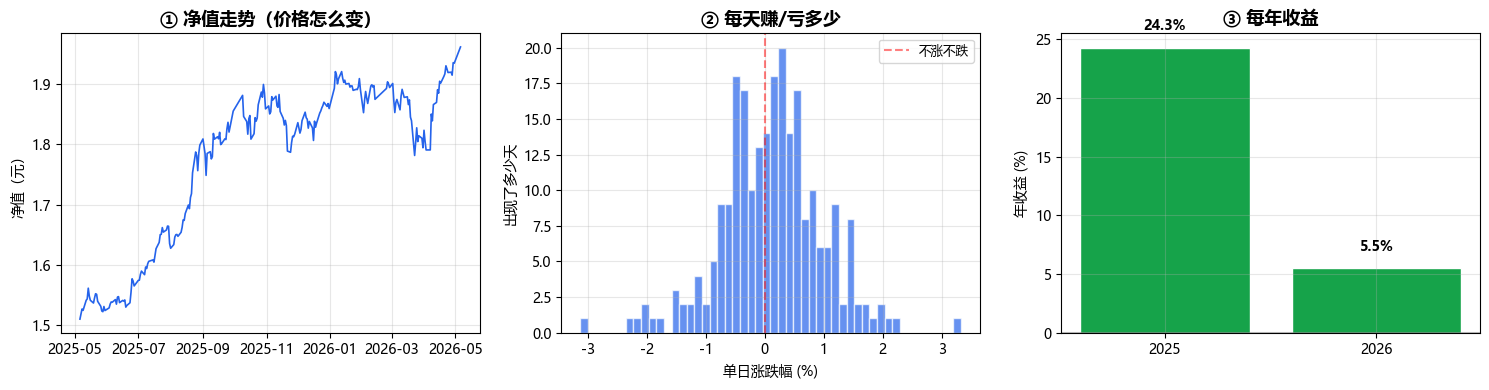


📊 三个角度看这只基金：
   ① 走势：价格一直在上下波动，但长期向上
   ② 日常：243 个交易日中，138 天涨，104 天跌
      → 大概 57% 的日子在涨
   ③ 每年：红色年份亏了，绿色年份赚了

💡 第二个道理：短期看运气，长期看趋势
   持有时间越长，赚钱的概率越高（统计规律，不是保证）


In [4]:
# 拉一只真实的基金来看看日常的涨跌
nav = get_fund_nav("110020")  # 易方达沪深300
returns = nav["daily_return"].dropna()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 图1：净值走势
axes[0].plot(nav["date"], nav["nav"], color="#2563EB", linewidth=1.2)
axes[0].set_title("① 净值走势（价格怎么变）", fontsize=13, fontweight="bold")
axes[0].set_ylabel("净值（元）")
axes[0].grid(True, alpha=0.3)

# 图2：日收益分布 — 大部分日子涨还是跌？
axes[1].hist(returns * 100, bins=50, color="#2563EB", alpha=0.7, edgecolor="white")
axes[1].axvline(x=0, color="red", linestyle="--", alpha=0.5, label="不涨不跌")
axes[1].set_title("② 每天赚/亏多少", fontsize=13, fontweight="bold")
axes[1].set_xlabel("单日涨跌幅 (%)")
axes[1].set_ylabel("出现了多少天")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

# 图3：分年统计 — 有的年份赚钱，有的年份亏钱
yearly = nav.copy()
yearly["year"] = yearly["date"].dt.year
yearly_returns = yearly.groupby("year")["daily_return"].apply(
    lambda x: (1 + x).prod() - 1
) * 100

colors_bar = ["#DC2626" if r < 0 else "#16A34A" for r in yearly_returns]
axes[2].bar(yearly_returns.index.astype(str), yearly_returns.values,
            color=colors_bar, edgecolor="white")
axes[2].axhline(y=0, color="gray", linestyle="-", alpha=0.5)
axes[2].set_title("③ 每年收益", fontsize=13, fontweight="bold")
axes[2].set_ylabel("年收益 (%)")
axes[2].grid(True, alpha=0.3)
for i, (idx, val) in enumerate(yearly_returns.items()):
    axes[2].text(i, val + (1.5 if val >= 0 else -4), f"{val:.1f}%",
                 ha="center", fontsize=10, fontweight="bold")

fig.tight_layout()
plt.show()

up_days = (returns > 0).sum()
down_days = (returns < 0).sum()
print(f"\n📊 三个角度看这只基金：")
print(f"   ① 走势：价格一直在上下波动，但长期向上")
print(f"   ② 日常：{len(returns)} 个交易日中，{up_days} 天涨，{down_days} 天跌")
print(f"      → 大概 {up_days/len(returns)*100:.0f}% 的日子在涨")
print(f"   ③ 每年：红色年份亏了，绿色年份赚了")
print(f"\n💡 第二个道理：短期看运气，长期看趋势")
print(f"   持有时间越长，赚钱的概率越高（统计规律，不是保证）")

## 第四讲：最大回撤——你最多能承受亏多少？

假设你花 **10 万块**买基金，经历了一段行情：

> 涨到 12 万 → 跌到 9 万 → 涨回 11 万

**最大回撤** = (12万 - 9万) / 12万 = **25%**

翻译：你最惨的时候，从最高点亏了 25%。

⚠️ **这个数字极其重要！** 因为它问的不是"我能赚多少"，而是：

> "假如我在最差的时机买入，又在最差的时机卖出，我会亏多少？"

在投资之前，先问自己：**我能承受亏 20% 吗？30% 呢？**

如果答案是"不能"，那就应该买风险更低的基金（比如债券基金）。

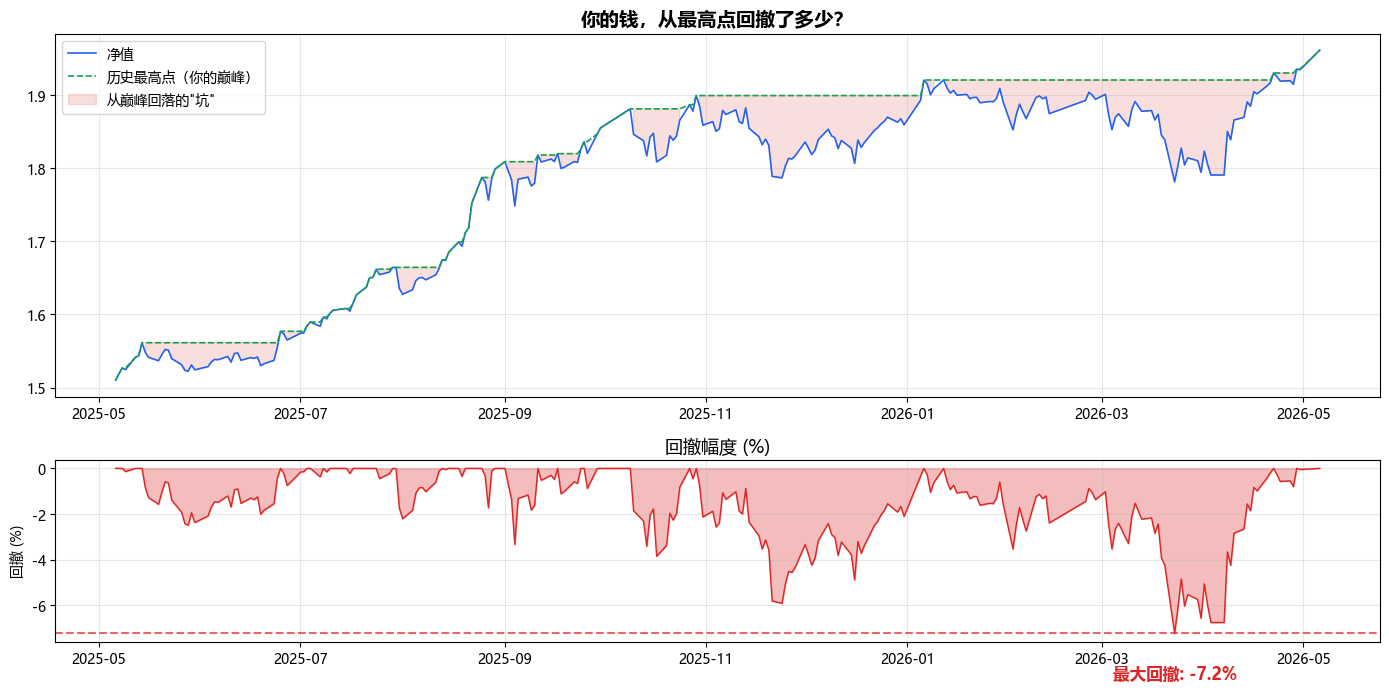


📉 最大回撤解读：
   这只基金最惨的时候，从最高点跌了 7.2%
   10 万在最差的时机买入并卖出，只剩 9.3 万

💡 第三个道理：选基金先看回撤，再看收益
   承受不了这个跌幅 → 别买这只基金
   每个人的承受能力不同 → 没有标准答案


In [5]:
nav = get_fund_nav("110020")

# 计算回撤：当前价格 相比 历史最高价，跌了多少
rolling_max = nav["nav"].cummax()  # 到这一天为止的历史最高价
drawdown = (nav["nav"] - rolling_max) / rolling_max * 100
max_dd = drawdown.min()  # 所有回撤中最惨的那一次
max_dd_idx = drawdown.idxmin()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7),
                                gridspec_kw={"height_ratios": [2, 1]})

# 上图：净值 + 历史最高点
ax1.plot(nav["date"], nav["nav"], color="#2563EB", linewidth=1.2, label="净值")
ax1.plot(nav["date"], rolling_max, color="#16A34A", linewidth=1.2,
         linestyle="--", label="历史最高点（你的巅峰）")
ax1.fill_between(nav["date"], nav["nav"], rolling_max,
                  where=(nav["nav"] < rolling_max),
                  alpha=0.15, color="#DC2626",
                  label='从巅峰回落的"坑"')
ax1.set_title("你的钱，从最高点回撤了多少？", fontsize=14, fontweight="bold")
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# 下图：回撤幅度 — 红色越深，跌得越惨
ax2.fill_between(nav["date"], drawdown, 0, color="#DC2626", alpha=0.3)
ax2.plot(nav["date"], drawdown, color="#DC2626", linewidth=1)
ax2.axhline(y=max_dd, color="#DC2626", linestyle="--", alpha=0.7)
ax2.text(nav["date"].iloc[max_dd_idx], max_dd - 2,
         f"最大回撤: {max_dd:.1f}%", fontsize=12,
         color="#DC2626", fontweight="bold", ha="center")
ax2.set_title("回撤幅度 (%)", fontsize=13)
ax2.set_ylabel("回撤 (%)")
ax2.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

print(f"\n📉 最大回撤解读：")
print(f"   这只基金最惨的时候，从最高点跌了 {abs(max_dd):.1f}%")
print(f"   10 万在最差的时机买入并卖出，只剩 {10*(1-abs(max_dd)/100):.1f} 万")
print(f"\n💡 第三个道理：选基金先看回撤，再看收益")
print(f"   承受不了这个跌幅 → 别买这只基金")
print(f"   每个人的承受能力不同 → 没有标准答案")

## 第五讲：定投——普通人最靠谱的赚钱方式

先讲一个**买鸡蛋**的故事。

小明和小红每个月都买鸡蛋：
- **小明（定投）**：每月固定花 100 块买鸡蛋
- **小红（凭感觉）**：哪个月觉得便宜多买，贵了就不买

鸡蛋价格：1元 → 0.6元 → 1.1元（先跌后涨）

| | 第1月(1元) | 第2月(0.6元) | 第3月(1.1元) | 总支出 | 鸡蛋数 | 均价 |
|---|---|---|---|---|---|---|
| 小明(定投) | 100元→100个 | 100元→**166个** | 100元→90个 | 300元 | **356个** | **0.84元** |
| 小红(预测) | 觉得贵→50个 | 等跌→0个 | 追涨→227个 | 300元 | 277个 | 1.08元 |

👆 这就是定投的**"微笑曲线"**效应：
- 跌的时候 → 同样的钱买到**更多份额**（100块在0.6元时买了166个！）
- 涨的时候 → 之前便宜买的那些**开始大赚**

小红以为自己能预测市场，结果高买低不买，成本反而更高。

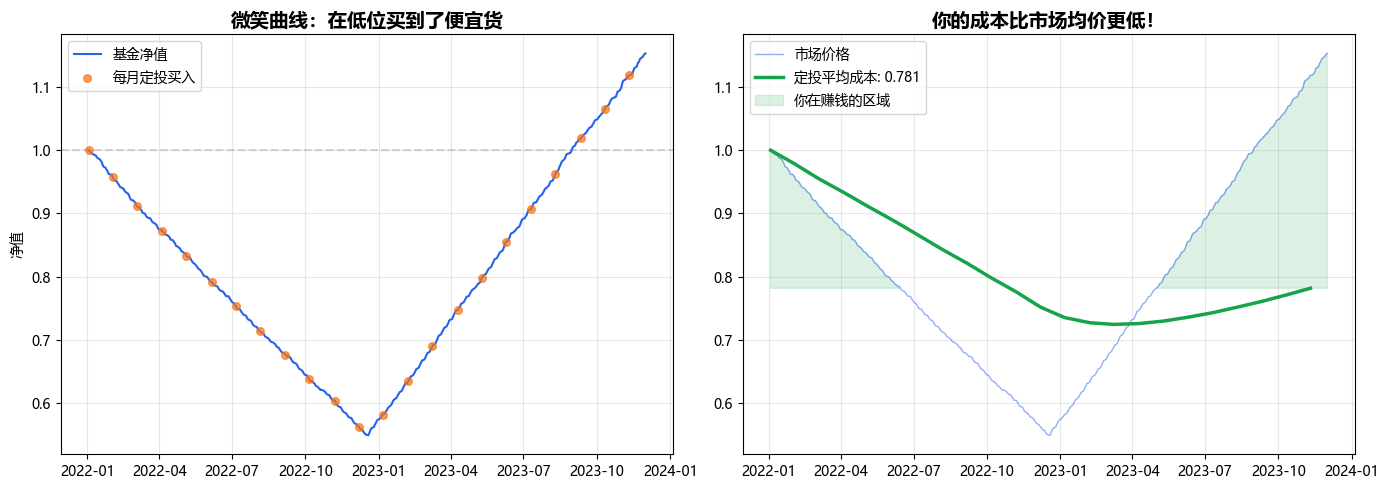


📊 结果对比（同样投入 23,000 元）：
   ┌────────────┬──────────┬──────────┐
   │            │  定投     │ 一次性   │
   ├────────────┼──────────┼──────────┤
   │ 最终资产    │   33,944  │   26,524  │
   │ 收益率      │    47.6%  │    15.3%  │
   │ 平均买入价  │  0.781   │  1.000   │
   │ 最低跌到    │  0.55    │   —      │
   └────────────┴──────────┴──────────┘

💡 第四个道理：
   在「先跌后涨」的行情中，定投 > 一次性投资
   因为在下跌时你买到了便宜的份额
   关键是你不需要预测市场——定投就是放弃预测，用纪律代替判断


In [6]:
# 模拟微笑曲线：市场先跌 45%，再涨回来
np.random.seed(42)
days = 500
trend = np.concatenate([
    np.linspace(1.0, 0.55, 250),   # 前半段：跌了 45%
    np.linspace(0.55, 1.15, 250),  # 后半段：涨回并创新高
])
noise = np.random.normal(0, 0.012, days)
sim_nav = trend * np.exp(noise.cumsum() * 0.08)
sim_nav = sim_nav / sim_nav[0]

dates = pd.date_range("2022-01-01", periods=days, freq="B")

# === 定投模拟 ===
invest_amount = 1000  # 每次投 1000 元
dca_shares = 0        # 累计份额
dca_invested = 0      # 累计投入
dca_costs = []         # 每期平均成本
buy_dates_list = []
buy_prices_list = []

for i in range(0, days, 22):  # 每月投一次
    price = sim_nav[i]
    dca_shares += invest_amount / price
    dca_invested += invest_amount
    avg_cost = dca_invested / dca_shares
    dca_costs.append(avg_cost)
    buy_dates_list.append(dates[i])
    buy_prices_list.append(price)

dca_final = dca_shares * sim_nav[-1]
dca_return = (dca_final - dca_invested) / dca_invested * 100

# === 一次性投资 ===
lump_final = (dca_invested / sim_nav[0]) * sim_nav[-1]
lump_return = (lump_final - dca_invested) / dca_invested * 100

# === 画图 ===
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 图1：微笑曲线 + 买入位置
ax1.plot(dates, sim_nav, color="#2563EB", linewidth=1.5, label="基金净值")
ax1.scatter(buy_dates_list, buy_prices_list, color="#F97316", s=30,
            alpha=0.7, zorder=5, label="每月定投买入")
ax1.axhline(y=1.0, color="gray", linestyle="--", alpha=0.3)
ax1.set_title("微笑曲线：在低位买到了便宜货", fontsize=14, fontweight="bold")
ax1.set_ylabel("净值")
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# 图2：定投成本 vs 市场价格
costs_arr = np.array(dca_costs)
dca_dates_arr = dates[::22][:len(dca_costs)]
ax2.plot(dates, sim_nav, color="#2563EB", alpha=0.5, linewidth=1, label="市场价格")
ax2.plot(dca_dates_arr, costs_arr, color="#16A34A", linewidth=2.5,
         label=f"定投平均成本: {dca_costs[-1]:.3f}")
ax2.fill_between(dates, sim_nav, dca_costs[-1],
                  where=(sim_nav > dca_costs[-1]),
                  alpha=0.15, color="#16A34A", label="你在赚钱的区域")
ax2.set_title(f"你的成本比市场均价更低！", fontsize=14, fontweight="bold")
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

print(f"\n📊 结果对比（同样投入 {dca_invested:,.0f} 元）：")
print(f"   ┌────────────┬──────────┬──────────┐")
print(f"   │            │  定投     │ 一次性   │")
print(f"   ├────────────┼──────────┼──────────┤")
print(f"   │ 最终资产    │ {dca_final:>8,.0f}  │ {lump_final:>8,.0f}  │")
print(f"   │ 收益率      │ {dca_return:>7.1f}%  │ {lump_return:>7.1f}%  │")
print(f"   │ 平均买入价  │  {dca_costs[-1]:.3f}   │  1.000   │")
print(f"   │ 最低跌到    │  0.55    │   —      │")
print(f"   └────────────┴──────────┴──────────┘")

print(f"\n💡 第四个道理：")
print(f"   在「先跌后涨」的行情中，定投 > 一次性投资")
print(f"   因为在下跌时你买到了便宜的份额")
print(f"   关键是你不需要预测市场——定投就是放弃预测，用纪律代替判断")

## 第六讲：不要把鸡蛋放在一个篮子里

假设你全部的钱买了白酒行业基金。

有一天，白酒行业出了利空（比如政策变化），你的钱瞬间缩水 30%。

但是，如果你这样配置：
- **50%** 宽基指数（跟着整个市场走）
- **30%** 债券基金（波动小，稳稳的）
- **20%** 白酒基金（搏一搏）

当白酒大跌 30%，你的总损失只有：20% × 30% = **6%**

因为另外 80% 的钱没有跟白酒一起跌。

👆 这就是**"分散投资"**——不是买很多只同类型的，而是买**不相关**的。

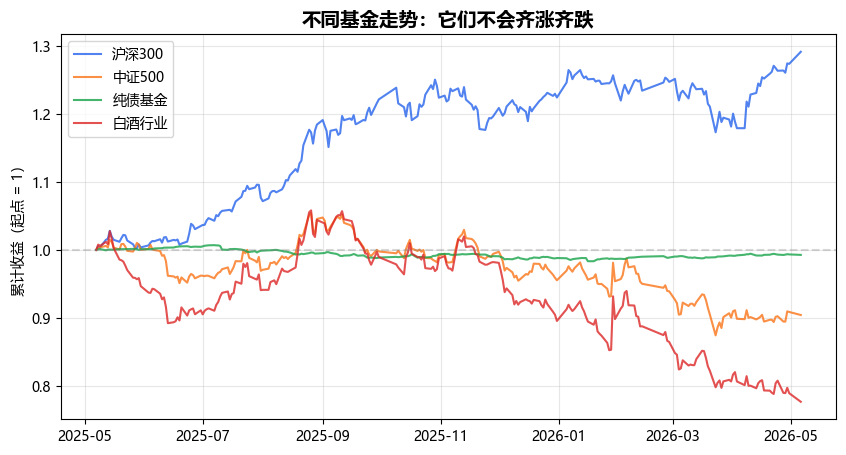


📊 这四只基金的「跟风程度」：
   （1.00 = 走势完全相同，0.00 = 各走各的）

   ➖ 有一定关联  沪深300 vs 中证500: 0.48
   ✅ 互相独立  沪深300 vs 纯债基金: -0.11
   ✅ 互相独立  沪深300 vs 白酒行业: 0.37
   ✅ 互相独立  中证500 vs 纯债基金: -0.03
   ⚠️ 高度同步  中证500 vs 白酒行业: 0.92
   ✅ 互相独立  纯债基金 vs 白酒行业: -0.05

💡 第五个道理：
   相关性低 = 它们各走各的，不会一起暴跌
   宽基指数 + 债券基金 = 最简单有效的分散配置
   买 10 只同类型基金 ≠ 分散，它们大概率同涨同跌


In [8]:
codes = ["110020", "001632", "050027", "161725"]
labels = {"110020": "沪深300", "001632": "中证500",
           "050027": "纯债基金", "161725": "白酒行业"}
colors_dict = {"110020": "#2563EB", "001632": "#F97316",
                "050027": "#16A34A", "161725": "#DC2626"}

fig, ax = plt.subplots(figsize=(10, 5))

all_returns = {}
for code in codes:
    try:
        n = get_fund_nav(code)
        n = n.set_index("date")["daily_return"].dropna()
        all_returns[code] = n
    except Exception:
        pass

if len(all_returns) >= 2:
    returns_df = pd.DataFrame(all_returns).dropna()
    cum_returns = (1 + returns_df).cumprod()
    cum_returns = cum_returns / cum_returns.iloc[0]

    for code in cum_returns.columns:
        ax.plot(cum_returns.index, cum_returns[code],
                color=colors_dict.get(code, "gray"), linewidth=1.5,
                label=f"{labels.get(code, code)}", alpha=0.8)

    ax.set_title("不同基金走势：它们不会齐涨齐跌", fontsize=14, fontweight="bold")
    ax.set_ylabel("累计收益（起点 = 1）")
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=1.0, color="gray", linestyle="--", alpha=0.3)
    plt.show()

    # 相关性数字
    corr = returns_df.corr()
    print("\n📊 这四只基金的「跟风程度」：")
    print("   （1.00 = 走势完全相同，0.00 = 各走各的）\n")
    for i, c1 in enumerate(corr.columns):
        for j, c2 in enumerate(corr.columns):
            if i < j:
                val = corr.loc[c1, c2]
                if val > 0.7:
                    s = "⚠️ 高度同步"
                elif val < 0.4:
                    s = "✅ 互相独立"
                else:
                    s = "➖ 有一定关联"
                print(f"   {s}  {labels.get(c1,c1)} vs {labels.get(c2,c2)}: {val:.2f}")

    print(f"\n💡 第五个道理：")
    print(f"   相关性低 = 它们各走各的，不会一起暴跌")
    print(f"   宽基指数 + 债券基金 = 最简单有效的分散配置")
    print(f"   买 10 只同类型基金 ≠ 分散，它们大概率同涨同跌")

## 第七讲：用自己的钱做计划

到这里，你已经理解了 5 个核心概念：

| 序号 | 大白话 | 专业术语 |
|------|--------|----------|
| ① | 大家凑钱请专家投资 | 基金 |
| ② | 每份值多少钱，天天在变 | 净值 |
| ③ | 最惨的时候亏多少 | 最大回撤 |
| ④ | 定期定额，不管涨跌都买 | 定投 |
| ⑤ | 别把钱都放一个地方 | 分散投资 |

现在，根据你自己的情况，做一个简单的投资计划。


📋 你的投资计划：
   ┌────────────────────────────┐
   │ 每月存入：       2,000 元       │
   │ 投资期限：          20 年         │
   │ 预期年化：          7%            │
   ├────────────────────────────┤
   │ 总投入：       480,000 元       │
   │ 最终预期：    1,041,853 元       │
   │ 其中收益：     561,853 元       │
   └────────────────────────────┘


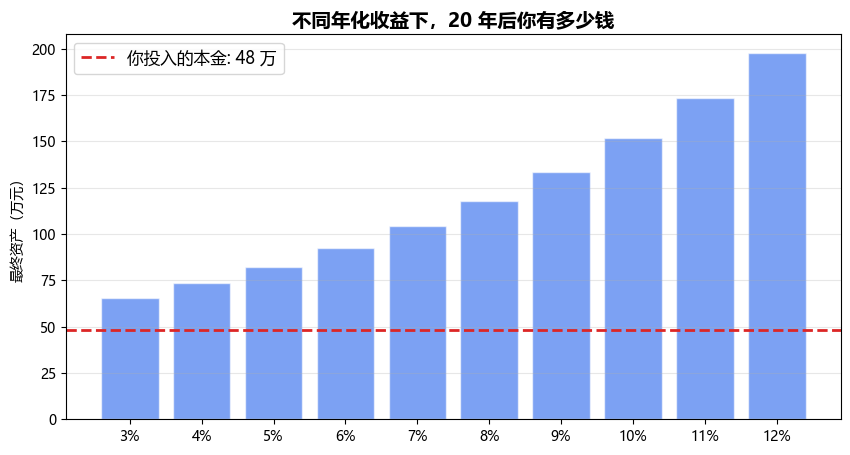


💡 最后一个道理：
   ① 尽早开始  >  等有钱了再开始
   ② 每月存 2000 坚持 20 年，不管收益率多少，都是一笔可观的钱
   ③ 收益率不是你能控制的，但「坚持投入」和「不放弃」是你能控制的
   ④ 投资最大的敌人不是市场，是恐慌时卖出、贪婪时追高


In [9]:
# 👇 修改下面的数字，试算你的投资计划
monthly_save = 2000      # 你每月能存多少？
years = 20               # 你打算投多少年？
expected_return = 0.07   # 预期年化收益率（保守估计 7%）

total_invested = monthly_save * 12 * years

# 复利公式：FV = PMT × [(1+r)^n - 1] / r
r = expected_return / 12
n = years * 12
final_value = monthly_save * ((1 + r)**n - 1) / r

print(f"\n📋 你的投资计划：")
print(f"   ┌────────────────────────────┐")
print(f"   │ 每月存入：    {monthly_save:>8,} 元       │")
print(f"   │ 投资期限：      {years:>6} 年         │")
print(f"   │ 预期年化：      {expected_return:>6.0%}            │")
print(f"   ├────────────────────────────┤")
print(f"   │ 总投入：      {total_invested:>8,} 元       │")
print(f"   │ 最终预期：    {final_value:>8,.0f} 元       │")
print(f"   │ 其中收益：    {final_value-total_invested:>8,.0f} 元       │")
print(f"   └────────────────────────────┘")

# 不同年化收益率下的终值对比
fig, ax = plt.subplots(figsize=(10, 5))
rates = np.linspace(0.03, 0.12, 10)
for rate in rates:
    r_m = rate / 12
    fv = monthly_save * ((1 + r_m)**n - 1) / r_m
    ax.bar(f"{rate*100:.0f}%", fv / 10000, color="#2563EB",
           alpha=0.6, edgecolor="white")

ax.axhline(y=total_invested/10000, color="#DC2626", linestyle="--", linewidth=2,
           label=f"你投入的本金: {total_invested/10000:.0f} 万")
ax.set_title(f"不同年化收益下，{years} 年后你有多少钱", fontsize=14, fontweight="bold")
ax.set_ylabel("最终资产（万元）")
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3, axis="y")
plt.show()

print(f"\n💡 最后一个道理：")
print(f"   ① 尽早开始  >  等有钱了再开始")
print(f"   ② 每月存 {monthly_save} 坚持 {years} 年，不管收益率多少，都是一笔可观的钱")
print(f"   ③ 收益率不是你能控制的，但「坚持投入」和「不放弃」是你能控制的")
print(f"   ④ 投资最大的敌人不是市场，是恐慌时卖出、贪婪时追高")

## 补充：常见问题速答

**Q: 我只有 1000 块，能买基金吗？**
A: 能。大部分基金 1 元起购，定投最低 100 元/月。

**Q: 买基金会不会亏光？**
A: 极难。基金持有几十上百只股票/债券，除非这些公司全部倒闭。相比之下，单买一只股票归零反而可能。

**Q: 什么时候开始最合适？**
A: 没人能预测最低点。定投的话，**今天就可以开始**。定投的精髓就是：不择时。

**Q: 买什么基金？**
A: 新手首选**宽基指数基金**，比如沪深300、中证500。不建议从白酒、新能源等行业基金开始——波动太大，新手容易恐慌卖出。

**Q: 应该持有多久？**
A: 统计上，持有 3 年以上赚钱概率大幅提高。持有 5 年以上，在很多市场接近 100%。（历史规律不代表保证）

**Q: 跌了怎么办？**
A: 定投的话：跌 = 打折促销，同样的钱买更多份额。一次性投的话：只要没卖出就不算亏，前提是买了优质基金。

**Q: 要不要每天看账户？**
A: **不要。** 越频繁看，越容易被短期波动影响情绪。建议一个月看一次。

## 📝 总结：记住这五句话就够了

| 序号 | 大白话 | 专业术语 |
|------|--------|----------|
| ① | 大家凑钱请专家投资 | 基金 |
| ② | 每份值多少钱，天天在变 | 净值 |
| ③ | 最惨的时候亏多少 | 最大回撤 |
| ④ | 定期定额，不管涨跌都买 | 定投 |
| ⑤ | 别把钱都放一个地方 | 分散投资 |

### 下一步学习路径

- 📖 `knowledge/01-基金基础/` — 系统了解基金分类
- 📖 `knowledge/02-投资入门/` — 深入理解复利和定投
- 📊 `01-你的第一笔基金数据.ipynb` — 动手操作，获取真实数据
- 📊 `02-基金对比与筛选.ipynb` — 学会比较基金好坏
- 📊 `03-定投策略回测.ipynb` — 用历史数据验证策略

### ⚠️ 免责声明
本项目中所有内容仅供学习参考，不构成投资建议。投资有风险，决策需谨慎。